# 02 - EDA: imbalance, missing values, outliers and distributions

**Concept:** Exploratory Data Analysis (EDA) is not "making pretty charts". It is **the stage where you discover the problems that will break the model** if they are not fixed.

This maps to the **Exploratory Data Analysis** section of the main notebook.

---

## The four EDA questions on a tabular problem

1. How is the **target** distributed? → is it imbalanced?
2. How many **missing values** are there, and where?
3. Are there **anomalous values** (outliers, sentinel codes)?
4. Does any variable **separate** the classes?

In [19]:
import sys
from pathlib import Path

# Lets us import `helpers.py` no matter which directory the notebook is opened from.
for _p in [Path.cwd(), Path.cwd() / "material_extra", Path.cwd().parent]:
    if (_p / "helpers.py").exists():
        sys.path.insert(0, str(_p))
        break

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import helpers

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
print("Original dataset available:", helpers.dataset_disponible())

Original dataset available: True


In [20]:
df = helpers.cargar_muestra(n=20_000)
df.shape

(20000, 21)

## 1. Class imbalance

We already saw this in notebook 01, but here we quantify why it is a problem.

In [21]:
base_rate = df["TARGET"].mean()
print(f"Default rate (share of TARGET=1): {base_rate:.2%}")
print(f"Negative:positive ratio ≈ {(1 - base_rate) / base_rate:.1f} : 1")
print()

# The "dumb model": always predict the majority class
dumb_accuracy = 1 - base_rate
print(f"Accuracy of a model that ALWAYS says 'repays': {dumb_accuracy:.2%}")
print("...and it detects 0 risky clients. Useless for the business.")

Default rate (share of TARGET=1): 8.24%
Negative:positive ratio ≈ 11.1 : 1

Accuracy of a model that ALWAYS says 'repays': 91.77%
...and it detects 0 risky clients. Useless for the business.


> **Rule of thumb:** once the minority class drops below ~20%, stop looking at accuracy. Use ROC AUC, PR AUC, recall or F1 depending on the cost of the error.

## 2. Missing values

`scikit-learn` **does not accept `NaN`** in most of its models. So this is not optional: it has to be dealt with.

                 nulos  porcentaje
EXT_SOURCE_1     11410       57.05
OCCUPATION_TYPE   6373       31.86
EXT_SOURCE_3      3915       19.58
EXT_SOURCE_2        57        0.29
AMT_GOODS_PRICE     19        0.10
AMT_ANNUITY          2        0.01


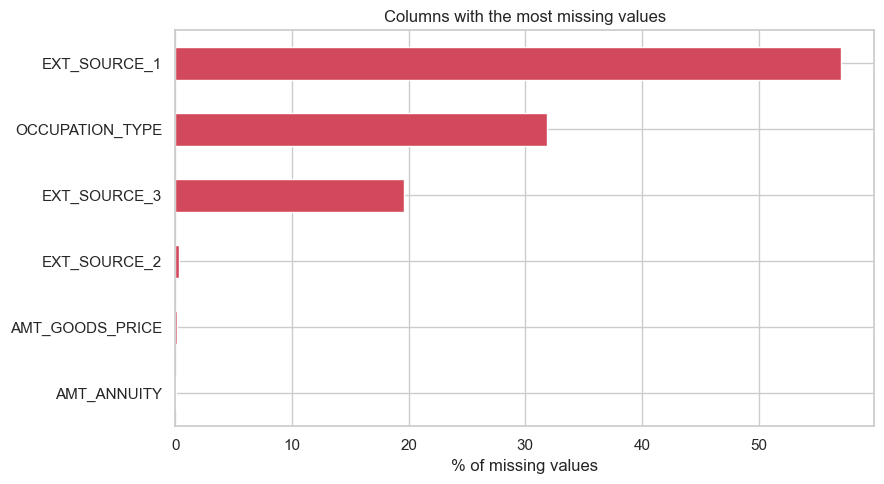

In [6]:
table = helpers.resumen_nulos(df, top=15)
print(table)

fig, ax = plt.subplots(figsize=(9, 5))
table.sort_values("porcentaje").plot.barh(y="porcentaje", ax=ax, legend=False, color="#d1495b")
ax.set_xlabel("% of missing values")
ax.set_ylabel("")
ax.set_title("Columns with the most missing values")
plt.tight_layout()
plt.show()

### Missingness is information too

Look at `EXT_SOURCE_1`: it is missing in more than half of the rows. But **the fact that it is missing can be predictive in itself** (perhaps it is missing because the client has no credit history, which is exactly what we are trying to measure).

Let's check it:

In [7]:
col = "EXT_SOURCE_1"
comparison = df.assign(is_missing=df[col].isnull()).groupby("is_missing")["TARGET"].agg(
    n="size", default_rate="mean"
)
comparison["default_rate"] = (comparison["default_rate"] * 100).round(2)
print(f"Default rate depending on whether '{col}' is present or not:\n")
print(comparison)

Default rate depending on whether 'EXT_SOURCE_1' is present or not:

                n  default_rate
is_missing                     
False        8590          7.57
True        11410          8.74


If the rates differ, it is worth creating a binary feature `EXT_SOURCE_1_missing`. **The project does not do this** (it imputes with the median and moves on), but it is one of the easiest improvements for the optional exercise.

## 3. Outliers and anomalous values

This is the classic gotcha of the Home Credit dataset.

DAYS_EMPLOYED (days employed, should be negative):
count     20000.0
mean      65678.0
std      142791.0
min      -17912.0
25%       -2718.0
50%       -1184.0
75%        -268.0
max      365243.0
Name: DAYS_EMPLOYED, dtype: float64


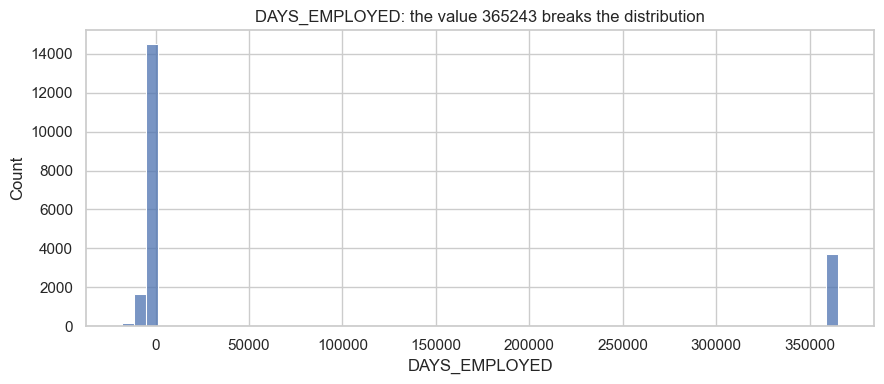

In [8]:
print("DAYS_EMPLOYED (days employed, should be negative):")
print(df["DAYS_EMPLOYED"].describe().round(0))

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df["DAYS_EMPLOYED"], bins=60, ax=ax, color="#4c72b0")
ax.set_title("DAYS_EMPLOYED: the value 365243 breaks the distribution")
plt.tight_layout()
plt.show()

### What is 365243?

`365243 / 365 ≈ 1000 years` of job seniority. Obviously not a real measurement: it is an anomalous value that we should manage.

If we leave it in:
- The mean and the median of the column are destroyed.
- `MinMaxScaler` will squash **all** the real values close to 0, because the maximum is 365243.

One fix in can be to replace it with `NaN` and let the imputer handle it:

In [9]:
anomalous = (df["DAYS_EMPLOYED"] == 365_243)
print(f"Rows with the anomalous value: {anomalous.sum():,} ({anomalous.mean():.1%})")
print()
print("Income type of those rows:")
print(df.loc[anomalous, "NAME_INCOME_TYPE"].value_counts().head())

# The correction the project applies
df_clean = df.copy()
df_clean.loc[anomalous, "DAYS_EMPLOYED"] = np.nan

print("\nAfter the fix:")
print(df_clean["DAYS_EMPLOYED"].describe().round(0))

Rows with the anomalous value: 3,702 (18.5%)

Income type of those rows:
Pensioner     3700
Unemployed       2
Name: NAME_INCOME_TYPE, dtype: int64

After the fix:
count    16298.0
mean     -2366.0
std       2340.0
min     -17912.0
25%      -3155.0
50%      -1621.0
75%       -751.0
max         -1.0
Name: DAYS_EMPLOYED, dtype: float64


In [22]:
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,OCCUPATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
0,210530,0,Cash loans,F,N,Y,0,180000.0,824823.0,29353.5,688500.0,Commercial associate,Secondary / secondary special,Married,-15465,-476,-6607.0,Core staff,0.549091,0.709192,0.526295
1,181647,0,Cash loans,M,Y,N,0,225000.0,643500.0,24934.5,643500.0,Working,Secondary / secondary special,Married,-17637,-179,-3766.0,Laborers,NaN,0.247351,0.320163
2,439708,0,Revolving loans,F,N,Y,1,135000.0,270000.0,13500.0,270000.0,Working,Secondary / secondary special,Separated,-11031,-931,-154.0,Sales staff,0.344145,0.624848,0.547810
3,216100,1,Cash loans,M,Y,Y,0,247500.0,545040.0,26640.0,450000.0,Working,Higher education,Married,-13100,-1750,-4015.0,Core staff,NaN,0.678473,0.554947
4,303234,1,Cash loans,M,N,Y,0,67500.0,545040.0,26640.0,450000.0,Working,Secondary / secondary special,Single / not married,-10669,-3025,-4217.0,Laborers,NaN,0.256370,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,346047,0,Cash loans,F,N,Y,0,157500.0,403249.5,18927.0,283500.0,Commercial associate,Secondary / secondary special,Married,-12727,-149,-1577.0,Sales staff,NaN,0.055831,0.454321
19996,329755,0,Cash loans,F,N,Y,0,495000.0,945000.0,40167.0,945000.0,Working,Higher education,Married,-17683,-1302,-4341.0,Accountants,0.833362,0.781955,0.616122
19997,305655,0,Cash loans,F,N,Y,0,135000.0,254700.0,14350.5,225000.0,Pensioner,Secondary / secondary special,Married,-24043,365243,-5573.0,NaN,0.855335,0.718465,0.634706
19998,454251,0,Cash loans,F,Y,Y,0,270000.0,1125000.0,37179.0,1125000.0,Commercial associate,Higher education,Married,-12211,-1691,-1107.0,NaN,0.782167,0.709304,0.377404


In [13]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
count,20000.000000,20000.000000,20000.000000,2.000000e+04,2.000000e+04,19998.000000,1.998100e+04,20000.000000,20000.000000,20000.000000,8590.000000,19943.000000,16085.000000
mean,278734.642850,0.082350,0.409700,1.680310e+05,5.999389e+05,27087.692394,5.388845e+05,-16076.825150,65678.089550,-5003.467550,0.501513,0.515889,0.508476
std,102685.707196,0.274904,0.715592,9.983873e+04,4.042120e+05,14203.768200,3.707166e+05,4371.281435,142790.853225,3529.278701,0.211484,0.190216,0.194533
min,100041.000000,0.000000,0.000000,2.700000e+04,4.500000e+04,2542.500000,4.500000e+04,-25192.000000,-17912.000000,-20840.000000,0.022117,0.000038,0.000527
25%,190041.750000,0.000000,0.000000,1.125000e+05,2.700000e+05,16582.500000,2.385000e+05,-19739.000000,-2718.000000,-7516.250000,0.333473,0.397210,0.367291
50%,279655.000000,0.000000,0.000000,1.485000e+05,5.173425e+05,25033.500000,4.500000e+05,-15782.000000,-1183.500000,-4521.000000,0.505264,0.565994,0.531686
75%,367406.750000,0.000000,1.000000,2.025000e+05,8.086500e+05,34536.375000,6.795000e+05,-12439.500000,-268.000000,-2020.000000,0.674180,0.664098,0.665855
max,456255.000000,1.000000,12.000000,4.500000e+06,4.050000e+06,173574.000000,4.050000e+06,-7489.000000,365243.000000,0.000000,0.941080,0.855000,0.882530


> **General lesson:** before scaling or imputing, look for impossible values. A `describe()` with an absurd `max` is the giveaway.

## 4. Which variables separate the classes?

Here we start to see whether the problem is solvable at all. We compare the distribution of each feature between `TARGET=0` and `TARGET=1`.

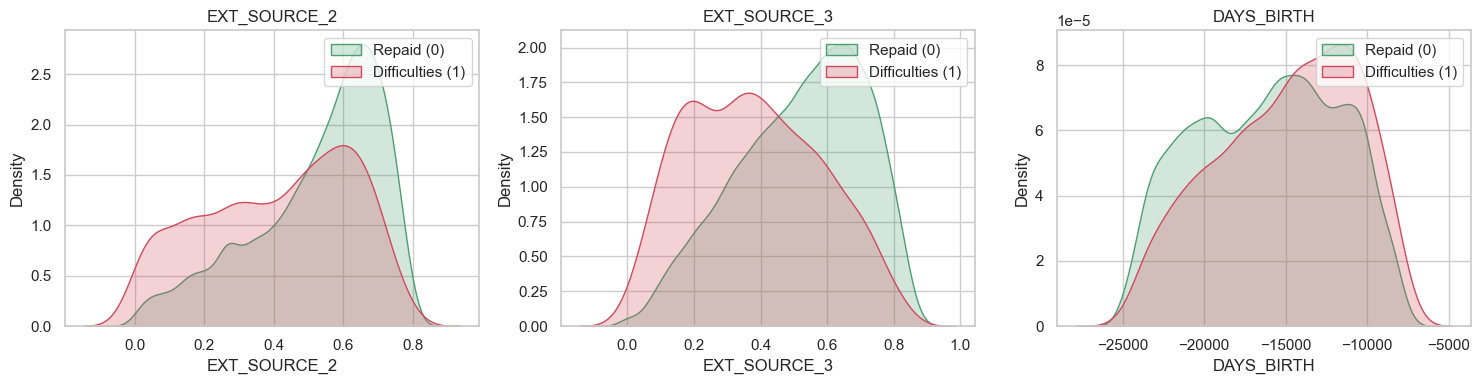

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["EXT_SOURCE_2", "EXT_SOURCE_3", "DAYS_BIRTH"]):
    for t, color, label in [(0, "#4c9f70", "Repaid (0)"), (1, "#d1495b", "Difficulties (1)")]:
        series = df_clean.loc[df_clean["TARGET"] == t, col].dropna()
        sns.kdeplot(series, ax=ax, color=color, label=label, fill=True, alpha=0.25)
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

The **further apart** the two curves are, the more predictive the variable is. `EXT_SOURCE_2` and `EXT_SOURCE_3` are usually the best ones in the dataset.





---

## Exercises

1. Build the default-rate table for `OCCUPATION_TYPE`. Which occupations are riskiest? How many rows does each one have (be careful with conclusions drawn from tiny groups)?
2. Create the feature `CREDIT_INCOME_RATIO = AMT_CREDIT / AMT_INCOME_TOTAL` and plot its distribution per class. Does it separate them?
3. `AMT_INCOME_TOTAL` has extreme outliers. Find the maximum and decide: do you clip it, transform it (`np.log1p`), or leave it alone? Justify your answer based on the model you are going to use (hint: a Random Forest doesn't mind, a logistic regression does).

In [ ]:
# Your turn
